<a href="https://colab.research.google.com/github/Karuneshtiwari/ML-lab/blob/main/Lab06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#A1- ChatGPT

from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import time
import numpy as np
import pandas as pd

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#A1 - ChatGPT

BASE_PATH = "/content/drive/MyDrive/ML_lab"
IMAGE_ROOT = os.path.join(BASE_PATH, "BreaKHis_v1")

CSV_PATH = os.path.join(
    BASE_PATH,
    "BreaKHis_metadata.csv"
)

SAMPLE_COUNT = 100
RESIZE_SHAPE = (16, 16)

DEFAULT_K = 3
DISTANCE = "euclidean"
SORT_METHOD = "insertion"

SEED = 42

Mounted at /content/drive


In [2]:
#A1/1 - ChatGPT

def locate_image(relative_name):
    relative_name = str(relative_name).replace("\\", "/")

    candidates = [
        os.path.join(BASE_PATH, relative_name),
        os.path.join(IMAGE_ROOT, relative_name)
    ]

    if relative_name.startswith("BreaKHis_v1/"):
        short_name = relative_name.split(
            "BreaKHis_v1/", 1
        )[1]

        candidates.append(
            os.path.join(IMAGE_ROOT, short_name)
        )

    for candidate in candidates:
        if os.path.isfile(candidate):
            return candidate

    return None


def get_target(path):
    path = str(path).lower()

    if "/benign/" in path:
        return "benign"

    if "/malignant/" in path:
        return "malignant"

    return None


def image_to_vector(path, size=(16, 16)):
    image = Image.open(path).convert("L")
    image = image.resize(size)

    values = np.asarray(
        image,
        dtype=np.float32
    )

    return values.reshape(-1)


def create_image_features(metadata, per_class=100):
    metadata = metadata.copy()

    metadata["target"] = metadata["filename"].map(
        get_target
    )

    metadata = metadata.dropna(
        subset=["target"]
    )

    selected_parts = []

    for target in ["benign", "malignant"]:

        class_rows = metadata[
            metadata["target"] == target
        ]

        selected_parts.append(
            class_rows.sample(
                n=min(per_class, len(class_rows)),
                random_state=SEED
            )
        )

    selected = pd.concat(
        selected_parts,
        ignore_index=True
    )

    features = []
    targets = []

    for _, record in selected.iterrows():

        image_path = locate_image(
            record["filename"]
        )

        if image_path is None:
            continue

        try:
            vector = image_to_vector(
                image_path,
                RESIZE_SHAPE
            )

            features.append(vector)
            targets.append(record["target"])

        except Exception:
            continue

    return (
        np.asarray(features, dtype=np.float32),
        np.asarray(targets)
    )

In [3]:
#A1/2 - ChatGPT

def encode_features(X):
    X = X.copy()

    for column in X.columns:

        if X[column].dtype == "object":

            values = X[column].dropna().unique()

            conversion = {
                value: position
                for position, value in enumerate(values)
            }

            X[column] = X[column].map(conversion)

    return X


def fill_missing(X, strategy="mean"):
    X = X.copy()

    for column in X.columns:

        if X[column].isna().any():

            if strategy == "mean":
                replacement = X[column].mean()

            elif strategy == "median":
                replacement = X[column].median()

            elif strategy == "mode":
                replacement = X[column].mode().iloc[0]

            else:
                raise ValueError(
                    "Use mean, median or mode."
                )

            X[column] = X[column].fillna(
                replacement
            )

    return X

In [4]:
#A1/3 - ChatGPT

def measure_distance(a, b, method="euclidean"):

    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    difference = a - b

    if method == "euclidean":
        return np.linalg.norm(difference)

    if method == "manhattan":
        return np.sum(np.abs(difference))

    raise ValueError(
        "Unsupported distance method."
    )

In [5]:
#A1/4- ChatGPT

def bubble_order(records):

    output = records.copy()

    for end in range(
        len(output) - 1,
        0,
        -1
    ):

        for current in range(end):

            if (
                output[current][0],
                output[current][2]
            ) > (
                output[current + 1][0],
                output[current + 1][2]
            ):

                output[current], output[current + 1] = (
                    output[current + 1],
                    output[current]
                )

    return output


    #A1 - ChatGPT

def selection_order(records):

    output = records.copy()

    for position in range(len(output)):

        best = position

        for candidate in range(
            position + 1,
            len(output)
        ):

            if (
                output[candidate][0],
                output[candidate][2]
            ) < (
                output[best][0],
                output[best][2]
            ):

                best = candidate

        if best != position:

            output[position], output[best] = (
                output[best],
                output[position]
            )

    return output


    #A1 - ChatGPT

def insertion_order(records):

    output = records.copy()

    for position in range(1, len(output)):

        item = output[position]

        cursor = position - 1

        while cursor >= 0:

            previous = (
                output[cursor][0],
                output[cursor][2]
            )

            current = (
                item[0],
                item[2]
            )

            if previous <= current:
                break

            output[cursor + 1] = output[cursor]

            cursor -= 1

        output[cursor + 1] = item

    return output




In [6]:
#A1/5- ChatGPT

def order_neighbors(records, method):

    sorters = {
        "bubble": bubble_order,
        "selection": selection_order,
        "insertion": insertion_order
    }

    if method not in sorters:
        raise ValueError(
            "Invalid sorting method."
        )

    return sorters[method](records)

In [7]:
#A1 - ChatGPT

def nearest_items(sorted_records, k):

    if k < 1:
        raise ValueError(
            "k must be positive."
        )

    if k > len(sorted_records):
        raise ValueError(
            "k cannot exceed training samples."
        )

    return sorted_records[:k]


def majority_class(neighbors):

    votes = {}

    for distance, label, index in neighbors:

        votes[label] = votes.get(
            label,
            0
        ) + 1

    highest = max(votes.values())

    winners = [
        label
        for label, count in votes.items()
        if count == highest
    ]

    if len(winners) == 1:
        return winners[0]

    for _, label, _ in neighbors:

        if label in winners:
            return label

In [8]:
#A1 - ChatGPT

def predict_custom_knn(
    X_train,
    y_train,
    X_test,
    k=3,
    distance_method="euclidean",
    sorting_method="insertion"
):

    predictions = []

    for sample in X_test:

        distances = []

        for row_id, train_sample in enumerate(X_train):

            distance = measure_distance(
                sample,
                train_sample,
                distance_method
            )

            distances.append(
                (
                    distance,
                    y_train[row_id],
                    row_id
                )
            )

        ordered = order_neighbors(
            distances,
            sorting_method
        )

        selected = nearest_items(
            ordered,
            k
        )

        predictions.append(
            majority_class(selected)
        )

    return np.asarray(predictions)

In [9]:
#A1/A2 - ChatGPT

def weighted_class(neighbors):

    scores = {}

    for distance, label, index in neighbors:

        weight = 1.0 / max(
            distance,
            1e-10
        )

        scores[label] = (
            scores.get(label, 0.0)
            + weight
        )

    return max(
        scores,
        key=scores.get
    )


def predict_weighted_knn(
    X_train,
    y_train,
    X_test,
    k=3,
    distance_method="euclidean",
    sorting_method="insertion"
):

    predictions = []

    for sample in X_test:

        distances = []

        for row_id, train_sample in enumerate(X_train):

            distance = measure_distance(
                sample,
                train_sample,
                distance_method
            )

            distances.append(
                (
                    distance,
                    y_train[row_id],
                    row_id
                )
            )

        ordered = order_neighbors(
            distances,
            sorting_method
        )

        selected = nearest_items(
            ordered,
            k
        )

        predictions.append(
            weighted_class(selected)
        )

    return np.asarray(predictions)

In [10]:
#A1/A3 - ChatGPT

def make_split(X, y, test_ratio=0.20):

    return train_test_split(
        X,
        y,
        test_size=test_ratio,
        random_state=SEED,
        stratify=y
    )

In [11]:
#A1/A4 - ChatGPT

def sklearn_classifier(
    X_train,
    y_train,
    k=3
):

    classifier = KNeighborsClassifier(
        n_neighbors=k,
        metric=DISTANCE
    )

    classifier.fit(
        X_train,
        y_train
    )

    return classifier

In [12]:
#A1/A5/A6 - ChatGPT

def get_accuracy(actual, predicted):

    return accuracy_score(
        actual,
        predicted
    )


def make_prediction_table(
    actual,
    predicted
):

    table = pd.DataFrame({
        "Actual": actual,
        "Predicted": predicted
    })

    table["Correct"] = (
        table["Actual"]
        == table["Predicted"]
    )

    return table

In [13]:
#A1/A7 - ChatGPT

class ImageKNN:

    def __init__(
        self,
        neighbors=3,
        metric="euclidean",
        sorting="insertion"
    ):

        self.neighbors = neighbors
        self.metric = metric
        self.sorting = sorting

        self.features = None
        self.labels = None

    def fit(self, X, y):

        self.features = np.asarray(
            X,
            dtype=float
        )

        self.labels = np.asarray(y)

        return self

    def predict(self, X):

        return predict_custom_knn(
            self.features,
            self.labels,
            np.asarray(X, dtype=float),
            self.neighbors,
            self.metric,
            self.sorting
        )

    def score(self, X, y):

        predictions = self.predict(X)

        return accuracy_score(
            y,
            predictions
        )

In [14]:
#A1/A8 - ChatGPT

def evaluate_k_values(
    X_train,
    y_train,
    X_test,
    y_test,
    values
):

    records = []

    for k in values:

        custom_pred = predict_custom_knn(
            X_train,
            y_train,
            X_test,
            k,
            DISTANCE,
            SORT_METHOD
        )

        library_model = sklearn_classifier(
            X_train,
            y_train,
            k
        )

        library_pred = library_model.predict(
            X_test
        )

        records.append({
            "k": k,
            "Custom": get_accuracy(
                y_test,
                custom_pred
            ),
            "Scikit-learn": get_accuracy(
                y_test,
                library_pred
            )
        })

    return pd.DataFrame(records)

In [15]:
#A1/A9 - ChatGPT

def evaluate_weighting(
    X_train,
    y_train,
    X_test,
    y_test,
    values
):

    records = []

    for k in values:

        normal = predict_custom_knn(
            X_train,
            y_train,
            X_test,
            k,
            DISTANCE,
            SORT_METHOD
        )

        weighted = predict_weighted_knn(
            X_train,
            y_train,
            X_test,
            k,
            DISTANCE,
            SORT_METHOD
        )

        records.append({
            "k": k,
            "Normal kNN": get_accuracy(
                y_test,
                normal
            ),
            "Weighted kNN": get_accuracy(
                y_test,
                weighted
            )
        })

    return pd.DataFrame(records)

In [16]:
#main

metadata = pd.read_csv(CSV_PATH)

X, y = create_image_features(
    metadata,
    per_class=SAMPLE_COUNT
)

print("Dataset Shape:", X.shape)
print("\nClass Distribution:")
print(pd.Series(y).value_counts())


#A1

X_train_demo, X_test_demo, y_train_demo, y_test_demo = make_split(
    X,
    y
)

single_prediction = predict_custom_knn(
    X_train_demo,
    y_train_demo,
    X_test_demo[:1],
    DEFAULT_K,
    DISTANCE,
    SORT_METHOD
)

print("\nA1")
print("Actual Class:", y_test_demo[0])
print("Predicted Class:", single_prediction[0])


#A2

weighted_prediction = predict_weighted_knn(
    X_train_demo,
    y_train_demo,
    X_test_demo[:1],
    DEFAULT_K,
    DISTANCE,
    SORT_METHOD
)

print("\nA2")
print("Actual Class:", y_test_demo[0])
print(
    "Weighted Prediction:",
    weighted_prediction[0]
)


#A3

print("\nA3")
print("Training Samples:", len(X_train_demo))
print("Testing Samples:", len(X_test_demo))


#A4

model = sklearn_classifier(
    X_train_demo,
    y_train_demo,
    DEFAULT_K
)

sklearn_predictions = model.predict(
    X_test_demo
)

print("\nA4")
print(
    "Scikit-learn kNN completed for k =",
    DEFAULT_K
)


#A5

accuracy = get_accuracy(
    y_test_demo,
    sklearn_predictions
)

print("\nA5")
print(
    "Scikit-learn Accuracy:",
    round(accuracy, 4)
)


#A6

prediction_results = make_prediction_table(
    y_test_demo,
    sklearn_predictions
)

print("\nA6")
display(
    prediction_results.head(10)
)


#A7

custom_model = ImageKNN(
    neighbors=DEFAULT_K,
    metric=DISTANCE,
    sorting=SORT_METHOD
)

custom_model.fit(
    X_train_demo,
    y_train_demo
)

custom_accuracy = custom_model.score(
    X_test_demo,
    y_test_demo
)

print("\nA7")
print(
    "Custom kNN Accuracy:",
    round(custom_accuracy, 4)
)


#A8

k_options = [1, 3, 5, 7, 9]

k_results = evaluate_k_values(
    X_train_demo,
    y_train_demo,
    X_test_demo,
    y_test_demo,
    k_options
)

print("\nA8")
display(k_results)


#A9

weight_results = evaluate_weighting(
    X_train_demo,
    y_train_demo,
    X_test_demo,
    y_test_demo,
    k_options
)

print("\nA9")
display(weight_results)

Dataset Shape: (200, 256)

Class Distribution:
benign       100
malignant    100
Name: count, dtype: int64

A1
Actual Class: benign
Predicted Class: benign

A2
Actual Class: benign
Weighted Prediction: benign

A3
Training Samples: 160
Testing Samples: 40

A4
Scikit-learn kNN completed for k = 3

A5
Scikit-learn Accuracy: 0.525

A6


,Actual,Predicted,Correct
0,benign,benign,True
1,malignant,malignant,True
2,malignant,malignant,True
3,malignant,malignant,True
4,benign,malignant,False
5,malignant,benign,False
6,benign,benign,True
7,malignant,malignant,True
8,malignant,malignant,True
9,benign,malignant,False



A7
Custom kNN Accuracy: 0.525

A8


,k,Custom,Scikit-learn
0,1,0.525,0.525
1,3,0.525,0.525
2,5,0.475,0.475
3,7,0.525,0.525
4,9,0.550,0.550



A9


,k,Normal kNN,Weighted kNN
0,1,0.525,0.525
1,3,0.525,0.525
2,5,0.475,0.475
3,7,0.525,0.525
4,9,0.550,0.550


A2 - ChatGPT

In [17]:
#A2 - ChatGPT

import unittest
import numpy as np
import pandas as pd
from PIL import Image
import tempfile
import os


class TestDistanceFunctions(unittest.TestCase):

    def test_euclidean_distance(self):
        result = measure_distance(
            [0, 0],
            [3, 4],
            "euclidean"
        )

        self.assertEqual(result, 5.0)

    def test_manhattan_distance(self):
        result = measure_distance(
            [1, 2],
            [4, 6],
            "manhattan"
        )

        self.assertEqual(result, 7)

    def test_invalid_distance(self):
        with self.assertRaises(ValueError):
            measure_distance(
                [1, 2],
                [3, 4],
                "invalid"
            )


class TestSortingFunctions(unittest.TestCase):

    def setUp(self):

        self.records = [
            (5.0, "A", 0),
            (2.0, "B", 1),
            (4.0, "A", 2),
            (1.0, "B", 3)
        ]

        self.expected = [
            (1.0, "B", 3),
            (2.0, "B", 1),
            (4.0, "A", 2),
            (5.0, "A", 0)
        ]

    def test_bubble_sort(self):

        result = bubble_order(
            self.records
        )

        self.assertEqual(
            result,
            self.expected
        )

    def test_selection_sort(self):

        result = selection_order(
            self.records
        )

        self.assertEqual(
            result,
            self.expected
        )

    def test_insertion_sort(self):

        result = insertion_order(
            self.records
        )

        self.assertEqual(
            result,
            self.expected
        )

    def test_sort_selector(self):

        for method in [
            "bubble",
            "selection",
            "insertion"
        ]:

            result = order_neighbors(
                self.records,
                method
            )

            self.assertEqual(
                result,
                self.expected
            )

    def test_invalid_sort(self):

        with self.assertRaises(ValueError):

            order_neighbors(
                self.records,
                "invalid"
            )


class TestNeighborFunctions(unittest.TestCase):

    def setUp(self):

        self.records = [
            (1.0, "benign", 0),
            (2.0, "malignant", 1),
            (3.0, "benign", 2),
            (4.0, "malignant", 3)
        ]

    def test_neighbor_selection(self):

        result = nearest_items(
            self.records,
            2
        )

        self.assertEqual(
            len(result),
            2
        )

    def test_invalid_k_zero(self):

        with self.assertRaises(ValueError):

            nearest_items(
                self.records,
                0
            )

    def test_invalid_k_large(self):

        with self.assertRaises(ValueError):

            nearest_items(
                self.records,
                10
            )

    def test_majority_class(self):

        result = majority_class(
            self.records[:3]
        )

        self.assertEqual(
            result,
            "benign"
        )


class TestWeightedKNN(unittest.TestCase):

    def test_weighted_class(self):

        neighbors = [
            (0.5, "benign", 0),
            (2.0, "malignant", 1),
            (3.0, "malignant", 2)
        ]

        result = weighted_class(
            neighbors
        )

        self.assertEqual(
            result,
            "benign"
        )

    def test_weighted_prediction(self):

        X_train = np.array([
            [0, 0],
            [0, 1],
            [10, 10],
            [10, 11]
        ])

        y_train = np.array([
            "benign",
            "benign",
            "malignant",
            "malignant"
        ])

        X_test = np.array([
            [0, 0.2]
        ])

        result = predict_weighted_knn(
            X_train,
            y_train,
            X_test,
            k=3,
            distance_method="euclidean",
            sorting_method="insertion"
        )

        self.assertEqual(
            result[0],
            "benign"
        )


class TestCustomKNN(unittest.TestCase):

    def setUp(self):

        self.X_train = np.array([
            [0, 0],
            [0, 1],
            [10, 10],
            [10, 11]
        ])

        self.y_train = np.array([
            "benign",
            "benign",
            "malignant",
            "malignant"
        ])

        self.X_test = np.array([
            [0, 0.2],
            [10, 10.2]
        ])

        self.y_test = np.array([
            "benign",
            "malignant"
        ])

    def test_custom_prediction(self):

        result = predict_custom_knn(
            self.X_train,
            self.y_train,
            self.X_test,
            k=3,
            distance_method="euclidean",
            sorting_method="insertion"
        )

        self.assertEqual(
            len(result),
            2
        )

    def test_custom_prediction_classes(self):

        result = predict_custom_knn(
            self.X_train,
            self.y_train,
            self.X_test,
            k=1,
            distance_method="euclidean",
            sorting_method="insertion"
        )

        self.assertEqual(
            result[0],
            "benign"
        )

        self.assertEqual(
            result[1],
            "malignant"
        )

    def test_image_knn_fit(self):

        model = ImageKNN(
            neighbors=3,
            metric="euclidean",
            sorting="insertion"
        )

        returned_model = model.fit(
            self.X_train,
            self.y_train
        )

        self.assertIs(
            returned_model,
            model
        )

        self.assertEqual(
            len(model.features),
            4
        )

    def test_image_knn_predict(self):

        model = ImageKNN(
            neighbors=1,
            metric="euclidean",
            sorting="insertion"
        )

        model.fit(
            self.X_train,
            self.y_train
        )

        result = model.predict(
            self.X_test
        )

        self.assertEqual(
            result[0],
            "benign"
        )

        self.assertEqual(
            result[1],
            "malignant"
        )

    def test_image_knn_score(self):

        model = ImageKNN(
            neighbors=1,
            metric="euclidean",
            sorting="insertion"
        )

        model.fit(
            self.X_train,
            self.y_train
        )

        score = model.score(
            self.X_test,
            self.y_test
        )

        self.assertEqual(
            score,
            1.0
        )


class TestPreprocessingFunctions(unittest.TestCase):

    def test_fill_missing_mean(self):

        data = pd.DataFrame({
            "A": [1, 2, np.nan, 4]
        })

        result = fill_missing(
            data,
            "mean"
        )

        self.assertFalse(
            result.isnull().any().any()
        )

        self.assertEqual(
            result.loc[2, "A"],
            7 / 3
        )

    def test_fill_missing_median(self):

        data = pd.DataFrame({
            "A": [1, 2, np.nan, 4]
        })

        result = fill_missing(
            data,
            "median"
        )

        self.assertEqual(
            result.loc[2, "A"],
            2.0
        )

    def test_fill_missing_mode(self):

        data = pd.DataFrame({
            "A": [1, 1, np.nan, 2]
        })

        result = fill_missing(
            data,
            "mode"
        )

        self.assertEqual(
            result.loc[2, "A"],
            1
        )

    def test_invalid_imputation(self):

        data = pd.DataFrame({
            "A": [1, np.nan, 2]
        })

        with self.assertRaises(ValueError):

            fill_missing(
                data,
                "invalid"
            )

    def test_encode_features(self):

        data = pd.DataFrame({
            "class": [
                "benign",
                "malignant",
                "benign"
            ]
        })

        result = encode_features(
            data
        )

        self.assertTrue(
            pd.api.types.is_numeric_dtype(
                result["class"]
            )
        )


class TestDatasetFunctions(unittest.TestCase):

    def test_image_vector(self):

        with tempfile.NamedTemporaryFile(
            suffix=".png",
            delete=False
        ) as file:

            file_path = file.name

        try:

            image = Image.new(
                "L",
                (4, 4),
                color=100
            )

            image.save(
                file_path
            )

            result = image_to_vector(
                file_path,
                (4, 4)
            )

            self.assertEqual(
                result.shape,
                (16,)
            )

        finally:

            if os.path.exists(file_path):
                os.remove(file_path)

    def test_target_detection(self):

        benign = get_target(
            "/breast/benign/image.png"
        )

        malignant = get_target(
            "/breast/malignant/image.png"
        )

        self.assertEqual(
            benign,
            "benign"
        )

        self.assertEqual(
            malignant,
            "malignant"
        )

    def test_unknown_target(self):

        result = get_target(
            "/breast/unknown/image.png"
        )

        self.assertIsNone(
            result
        )

    def test_missing_image_path(self):

        result = locate_image(
            "not_existing_image.png"
        )

        self.assertIsNone(
            result
        )


class TestSplitFunction(unittest.TestCase):

    def test_train_test_split(self):

        X = np.arange(100).reshape(
            50,
            2
        )

        y = np.array(
            ["A"] * 25 +
            ["B"] * 25
        )

        X_train, X_test, y_train, y_test = make_split(
            X,
            y,
            test_ratio=0.2
        )

        self.assertEqual(
            len(X_train),
            40
        )

        self.assertEqual(
            len(X_test),
            10
        )

        self.assertEqual(
            len(y_train),
            40
        )

        self.assertEqual(
            len(y_test),
            10
        )


class TestSklearnFunctions(unittest.TestCase):

    def test_sklearn_classifier(self):

        X_train = np.array([
            [0, 0],
            [0, 1],
            [10, 10],
            [10, 11]
        ])

        y_train = np.array([
            "benign",
            "benign",
            "malignant",
            "malignant"
        ])

        model = sklearn_classifier(
            X_train,
            y_train,
            k=1
        )

        prediction = model.predict(
            np.array([[0, 0]])
        )

        self.assertEqual(
            prediction[0],
            "benign"
        )


class TestEvaluationFunctions(unittest.TestCase):

    def test_accuracy(self):

        actual = [
            "A",
            "B",
            "A",
            "B"
        ]

        predicted = [
            "A",
            "B",
            "B",
            "B"
        ]

        result = get_accuracy(
            actual,
            predicted
        )

        self.assertEqual(
            result,
            0.75
        )

    def test_prediction_table(self):

        actual = [
            "A",
            "B"
        ]

        predicted = [
            "A",
            "A"
        ]

        result = make_prediction_table(
            actual,
            predicted
        )

        self.assertEqual(
            len(result),
            2
        )

        self.assertTrue(
            result.loc[0, "Correct"]
        )

        self.assertFalse(
            result.loc[1, "Correct"]
        )

In [18]:
#main - A2

test_classes = [
    TestDistanceFunctions,
    TestSortingFunctions,
    TestNeighborFunctions,
    TestWeightedKNN,
    TestCustomKNN,
    TestPreprocessingFunctions,
    TestDatasetFunctions,
    TestSplitFunction,
    TestSklearnFunctions,
    TestEvaluationFunctions
]

all_results = []

total_tests = 0
passed_tests = 0
failed_tests = 0

for test_class in test_classes:

    suite = unittest.TestLoader().loadTestsFromTestCase(
        test_class
    )

    result = unittest.TestResult()

    suite.run(result)

    class_total = (
        result.testsRun
    )

    class_failed = (
        len(result.failures)
        + len(result.errors)
    )

    class_passed = (
        class_total - class_failed
    )

    total_tests += class_total
    passed_tests += class_passed
    failed_tests += class_failed

    all_results.append({
        "Test Class": test_class.__name__,
        "Total": class_total,
        "Passed": class_passed,
        "Failed": class_failed,
        "Status": (
            "PASS"
            if class_failed == 0
            else "FAIL"
        )
    })


print("A2 - Unit Testing")
print()
print(
    "Total Tests:",
    total_tests
)

print(
    "Passed:",
    passed_tests
)

print(
    "Failed:",
    failed_tests
)

print()

test_summary = pd.DataFrame(
    all_results
)

display(test_summary)

print(
    "\nOverall Status:",
    "PASS"
    if failed_tests == 0
    else "FAIL"
)

A2 - Unit Testing

Total Tests: 32
Passed: 32
Failed: 0



,Test Class,Total,Passed,Failed,Status
0,TestDistanceFunctions,3,3,0,PASS
1,TestSortingFunctions,5,5,0,PASS
2,TestNeighborFunctions,4,4,0,PASS
3,TestWeightedKNN,2,2,0,PASS
4,TestCustomKNN,5,5,0,PASS
5,TestPreprocessingFunctions,5,5,0,PASS
6,TestDatasetFunctions,4,4,0,PASS
7,TestSplitFunction,1,1,0,PASS
8,TestSklearnFunctions,1,1,0,PASS
9,TestEvaluationFunctions,2,2,0,PASS



Overall Status: PASS


A3 — Performance Comparison


In [19]:
#A3 - ChatGPT

def ai_knn_predict(X_train, y_train, X_test, k=3):

    X_train = np.asarray(X_train, dtype=float)
    X_test = np.asarray(X_test, dtype=float)
    y_train = np.asarray(y_train)

    predictions = []

    for test_sample in X_test:

        distance_values = np.sqrt(
            np.sum(
                (X_train - test_sample) ** 2,
                axis=1
            )
        )

        nearest_indices = np.argsort(
            distance_values
        )[:k]

        nearest_labels = y_train[
            nearest_indices
        ]

        labels, counts = np.unique(
            nearest_labels,
            return_counts=True
        )

        prediction = labels[
            np.argmax(counts)
        ]

        predictions.append(
            prediction
        )

    return np.asarray(predictions)

In [20]:
#A3 - ChatGPT

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


def calculate_metrics(y_actual, y_predicted):

    return {
        "Accuracy": accuracy_score(
            y_actual,
            y_predicted
        ),

        "Precision": precision_score(
            y_actual,
            y_predicted,
            average="binary",
            pos_label="malignant",
            zero_division=0
        ),

        "Recall": recall_score(
            y_actual,
            y_predicted,
            average="binary",
            pos_label="malignant",
            zero_division=0
        ),

        "F1-Score": f1_score(
            y_actual,
            y_predicted,
            average="binary",
            pos_label="malignant",
            zero_division=0
        )
    }

In [21]:
#A3 - ChatGPT

def average_runtime(
    prediction_function,
    X_test,
    runs=10
):

    execution_times = []

    for _ in range(runs):

        start_time = time.perf_counter()

        prediction_function(
            X_test
        )

        end_time = time.perf_counter()

        execution_times.append(
            end_time - start_time
        )

    return np.mean(
        execution_times
    ), execution_times

In [22]:
#A3 - ChatGPT

X_A3 = X.copy()
y_A3 = y.copy()

X_train_A3, X_test_A3, y_train_A3, y_test_A3 = make_split(
    X_A3,
    y_A3,
    test_ratio=0.20
)

print("A3 Dataset")
print("Total Samples:", len(X_A3))
print("Training Samples:", len(X_train_A3))
print("Testing Samples:", len(X_test_A3))
print("Feature Dimension:", X_A3.shape[1])

A3 Dataset
Total Samples: 200
Training Samples: 160
Testing Samples: 40
Feature Dimension: 256


In [23]:
#A3 - ChatGPT

K_VALUES = [1, 3, 5, 7, 9]

implementation_results = []

In [24]:
#main - A3

for k in K_VALUES:

    #Your Custom kNN

    def run_custom(X_test):
        return predict_custom_knn(
            X_train_A3,
            y_train_A3,
            X_test,
            k=k,
            distance_method="euclidean",
            sorting_method="insertion"
        )

    custom_prediction = run_custom(
        X_test_A3
    )

    custom_metrics = calculate_metrics(
        y_test_A3,
        custom_prediction
    )

    custom_time, custom_runs = average_runtime(
        run_custom,
        X_test_A3,
        runs=10
    )


    #Scikit-learn kNN

    sklearn_model = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean"
    )

    sklearn_model.fit(
        X_train_A3,
        y_train_A3
    )

    def run_sklearn(X_test):
        return sklearn_model.predict(
            X_test
        )

    sklearn_prediction = run_sklearn(
        X_test_A3
    )

    sklearn_metrics = calculate_metrics(
        y_test_A3,
        sklearn_prediction
    )

    sklearn_time, sklearn_runs = average_runtime(
        run_sklearn,
        X_test_A3,
        runs=10
    )


    #GenAI kNN

    def run_ai(X_test):
        return ai_knn_predict(
            X_train_A3,
            y_train_A3,
            X_test,
            k=k
        )

    ai_prediction = run_ai(
        X_test_A3
    )

    ai_metrics = calculate_metrics(
        y_test_A3,
        ai_prediction
    )

    ai_time, ai_runs = average_runtime(
        run_ai,
        X_test_A3,
        runs=10
    )


    implementation_results.append({
        "k": k,
        "Implementation": "Custom kNN",
        "Accuracy": custom_metrics["Accuracy"],
        "Precision": custom_metrics["Precision"],
        "Recall": custom_metrics["Recall"],
        "F1-Score": custom_metrics["F1-Score"],
        "Average Time (s)": custom_time
    })


    implementation_results.append({
        "k": k,
        "Implementation": "Scikit-learn kNN",
        "Accuracy": sklearn_metrics["Accuracy"],
        "Precision": sklearn_metrics["Precision"],
        "Recall": sklearn_metrics["Recall"],
        "F1-Score": sklearn_metrics["F1-Score"],
        "Average Time (s)": sklearn_time
    })


    implementation_results.append({
        "k": k,
        "Implementation": "GenAI kNN",
        "Accuracy": ai_metrics["Accuracy"],
        "Precision": ai_metrics["Precision"],
        "Recall": ai_metrics["Recall"],
        "F1-Score": ai_metrics["F1-Score"],
        "Average Time (s)": ai_time
    })


results_A3 = pd.DataFrame(
    implementation_results
)

print("\nA3 Performance Comparison")

display(
    results_A3.round(4)
)


A3 Performance Comparison


,k,Implementation,Accuracy,Precision,Recall,F1-Score,Average Time (s)
0,1,Custom kNN,0.525,0.5172,0.75,0.6122,0.1709
1,1,Scikit-learn kNN,0.525,0.5172,0.75,0.6122,0.0016
2,1,GenAI kNN,0.525,0.5172,0.75,0.6122,0.0052
3,3,Custom kNN,0.525,0.5172,0.75,0.6122,0.1605
4,3,Scikit-learn kNN,0.525,0.5172,0.75,0.6122,0.0024
5,3,GenAI kNN,0.525,0.5172,0.75,0.6122,0.0074
6,5,Custom kNN,0.475,0.4828,0.70,0.5714,0.2068
7,5,Scikit-learn kNN,0.475,0.4828,0.70,0.5714,0.0027
8,5,GenAI kNN,0.475,0.4828,0.70,0.5714,0.0090
9,7,Custom kNN,0.525,0.5200,0.65,0.5778,0.1465


In [25]:
#A3

summary_A3 = results_A3.copy()

summary_A3["Average Time (ms)"] = (
    summary_A3["Average Time (s)"] * 1000
)

summary_A3 = summary_A3.drop(
    columns=["Average Time (s)"]
)

display(
    summary_A3.round(3)
)

,k,Implementation,Accuracy,Precision,Recall,F1-Score,Average Time (ms)
0,1,Custom kNN,0.525,0.517,0.75,0.612,170.882
1,1,Scikit-learn kNN,0.525,0.517,0.75,0.612,1.606
2,1,GenAI kNN,0.525,0.517,0.75,0.612,5.187
3,3,Custom kNN,0.525,0.517,0.75,0.612,160.471
4,3,Scikit-learn kNN,0.525,0.517,0.75,0.612,2.419
5,3,GenAI kNN,0.525,0.517,0.75,0.612,7.384
6,5,Custom kNN,0.475,0.483,0.70,0.571,206.784
7,5,Scikit-learn kNN,0.475,0.483,0.70,0.571,2.707
8,5,GenAI kNN,0.475,0.483,0.70,0.571,8.972
9,7,Custom kNN,0.525,0.520,0.65,0.578,146.508


In [26]:
#A3

best_accuracy = results_A3.loc[
    results_A3["Accuracy"].idxmax()
]

best_precision = results_A3.loc[
    results_A3["Precision"].idxmax()
]

best_recall = results_A3.loc[
    results_A3["Recall"].idxmax()
]

best_f1 = results_A3.loc[
    results_A3["F1-Score"].idxmax()
]

fastest = results_A3.loc[
    results_A3["Average Time (s)"].idxmin()
]

print("Best Accuracy:")
display(
    best_accuracy.to_frame().T.round(4)
)

print("\nBest Precision:")
display(
    best_precision.to_frame().T.round(4)
)

print("\nBest Recall:")
display(
    best_recall.to_frame().T.round(4)
)

print("\nBest F1-Score:")
display(
    best_f1.to_frame().T.round(4)
)

print("\nFastest Implementation:")
display(
    fastest.to_frame().T.round(6)
)

Best Accuracy:


,k,Implementation,Accuracy,Precision,Recall,F1-Score,Average Time (s)
12,9,Custom kNN,0.55,0.541667,0.65,0.590909,0.104638



Best Precision:


,k,Implementation,Accuracy,Precision,Recall,F1-Score,Average Time (s)
12,9,Custom kNN,0.55,0.541667,0.65,0.590909,0.104638



Best Recall:


,k,Implementation,Accuracy,Precision,Recall,F1-Score,Average Time (s)
0,1,Custom kNN,0.525,0.517241,0.75,0.612245,0.170882



Best F1-Score:


,k,Implementation,Accuracy,Precision,Recall,F1-Score,Average Time (s)
0,1,Custom kNN,0.525,0.517241,0.75,0.612245,0.170882



Fastest Implementation:


,k,Implementation,Accuracy,Precision,Recall,F1-Score,Average Time (s)
1,1,Scikit-learn kNN,0.525,0.517241,0.75,0.612245,0.001606


In [27]:
#A3

k3_comparison = results_A3[
    results_A3["k"] == 3
].copy()

k3_comparison = k3_comparison[
    [
        "Implementation",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Average Time (s)"
    ]
]

display(
    k3_comparison.round(5)
)

,Implementation,Accuracy,Precision,Recall,F1-Score,Average Time (s)
3,Custom kNN,0.525,0.51724,0.75,0.61224,0.16047
4,Scikit-learn kNN,0.525,0.51724,0.75,0.61224,0.00242
5,GenAI kNN,0.525,0.51724,0.75,0.61224,0.00738


In [28]:
#A3

runtime_table = results_A3[
    [
        "k",
        "Implementation",
        "Average Time (s)"
    ]
].copy()

runtime_table["Average Time (ms)"] = (
    runtime_table["Average Time (s)"] * 1000
)

runtime_table = runtime_table.drop(
    columns=["Average Time (s)"]
)

display(
    runtime_table.round(4)
)

,k,Implementation,Average Time (ms)
0,1,Custom kNN,170.8816
1,1,Scikit-learn kNN,1.6064
2,1,GenAI kNN,5.1870
3,3,Custom kNN,160.4713
4,3,Scikit-learn kNN,2.4187
5,3,GenAI kNN,7.3838
6,5,Custom kNN,206.7836
7,5,Scikit-learn kNN,2.7072
8,5,GenAI kNN,8.9721
9,7,Custom kNN,146.5075


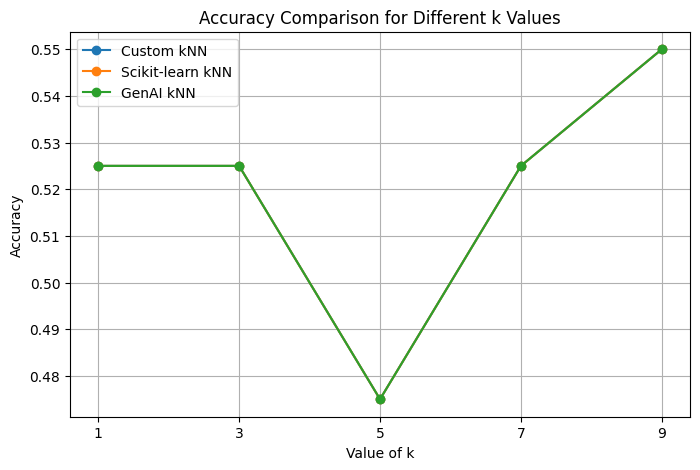

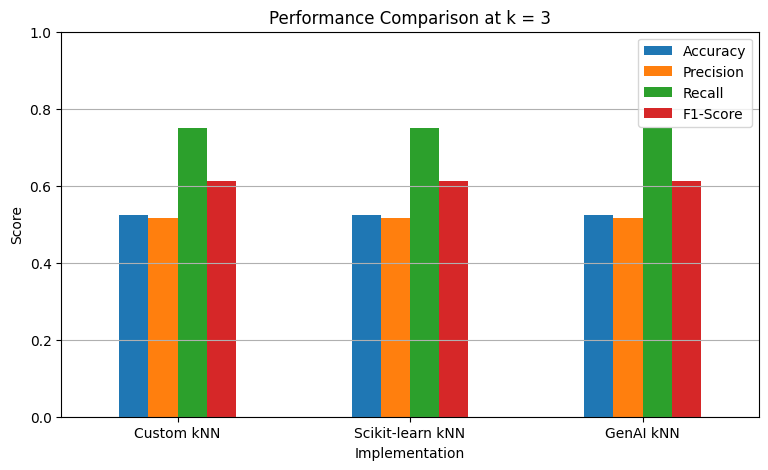

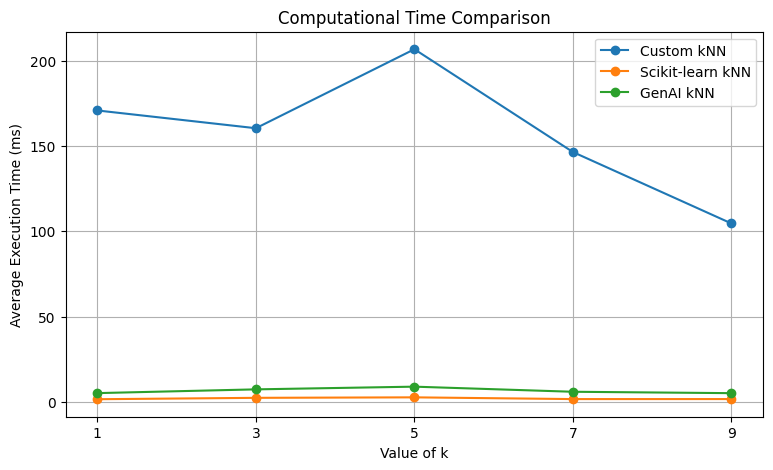

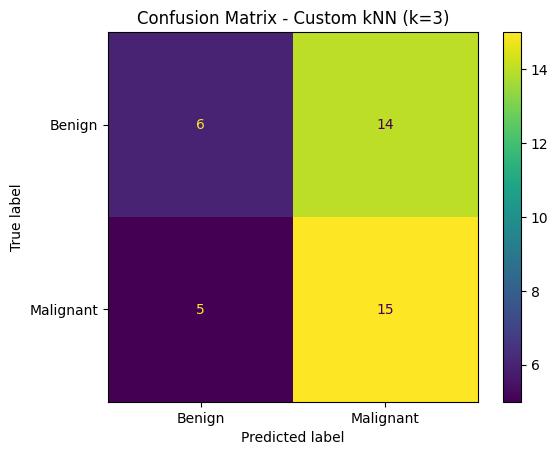

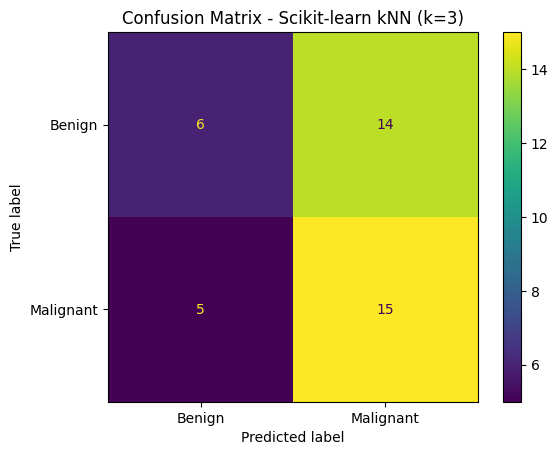

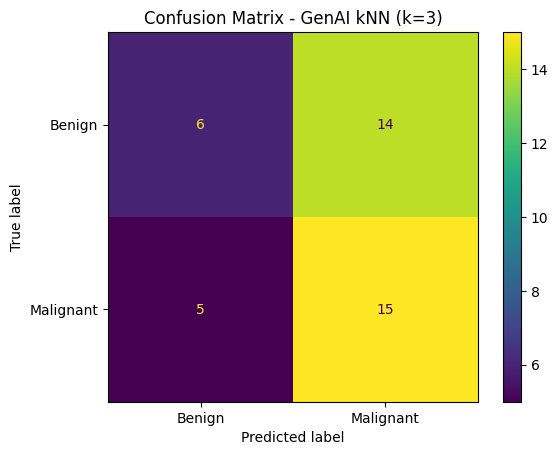

In [33]:
#A3

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for implementation in results_A3["Implementation"].unique():

    subset = results_A3[
        results_A3["Implementation"] == implementation
    ]

    plt.plot(
        subset["k"],
        subset["Accuracy"],
        marker="o",
        label=implementation
    )

plt.xlabel("Value of k")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison for Different k Values")
plt.xticks(K_VALUES)
plt.legend()
plt.grid(True)
plt.show()


#A3

k3_metrics = results_A3[
    results_A3["k"] == 3
].copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

plot_data = k3_metrics.set_index(
    "Implementation"
)[metric_columns]

plot_data.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Implementation")
plt.ylabel("Score")
plt.title("Performance Comparison at k = 3")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y")
plt.show()



#A3

runtime_plot = results_A3.copy()

runtime_plot["Average Time (ms)"] = (
    runtime_plot["Average Time (s)"] * 1000
)

plt.figure(figsize=(9, 5))

for implementation in runtime_plot["Implementation"].unique():

    subset = runtime_plot[
        runtime_plot["Implementation"] == implementation
    ]

    plt.plot(
        subset["k"],
        subset["Average Time (ms)"],
        marker="o",
        label=implementation
    )

plt.xlabel("Value of k")
plt.ylabel("Average Execution Time (ms)")
plt.title("Computational Time Comparison")
plt.xticks(K_VALUES)
plt.legend()
plt.grid(True)
plt.show()

#A3

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

k = 3

custom_prediction = predict_custom_knn(
    X_train_A3,
    y_train_A3,
    X_test_A3,
    k=k,
    distance_method="euclidean",
    sorting_method="insertion"
)

sklearn_model = KNeighborsClassifier(
    n_neighbors=k,
    metric="euclidean"
)

sklearn_model.fit(
    X_train_A3,
    y_train_A3
)

sklearn_prediction = sklearn_model.predict(
    X_test_A3
)

ai_prediction = ai_knn_predict(
    X_train_A3,
    y_train_A3,
    X_test_A3,
    k=k
)

predictions = {
    "Custom kNN": custom_prediction,
    "Scikit-learn kNN": sklearn_prediction,
    "GenAI kNN": ai_prediction
}

for name, prediction in predictions.items():

    matrix = confusion_matrix(
        y_test_A3,
        prediction,
        labels=["benign", "malignant"]
    )

    display_plot = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["Benign", "Malignant"]
    )

    display_plot.plot()

    plt.title(
        f"Confusion Matrix - {name} (k={k})"
    )

    plt.show()

